In [30]:
from sklearn import discriminant_analysis, naive_bayes, metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
import numpy as np

In [31]:
qda = discriminant_analysis.QuadraticDiscriminantAnalysis()
lda = discriminant_analysis.LinearDiscriminantAnalysis()
nb = naive_bayes.GaussianNB()

In [32]:
iris = datasets.load_iris()
train_features, test_features, train_target, test_target = train_test_split(iris.data, iris.target, test_size=0.33, random_state=21)

Text(0.5, 20.222222222222214, 'Predicted')

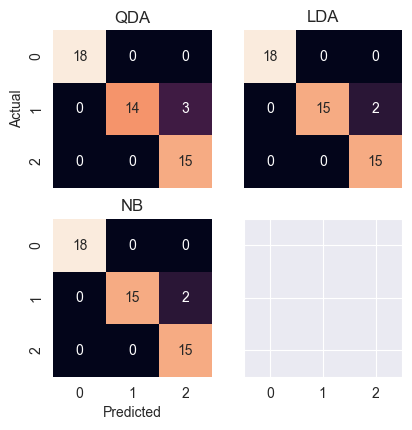

In [33]:
da_methods = [qda, lda, nb]
names = ['QDA', 'LDA', 'NB']

fig, axes = plt.subplots(2,2, figsize=(4.5, 4.5),
                         sharex=True, sharey = True)
for ax, model, name in zip(axes.flat, da_methods, names):
    preds = (model.fit(train_features, train_target)
      .predict(test_features))
    cm = metrics.confusion_matrix(test_target, preds)

    sns.heatmap(cm, annot=True, cbar=False, ax=ax)
    ax.set_title(name)
axes[0,0].set_ylabel('Actual')
axes[1,0].set_xlabel('Predicted')

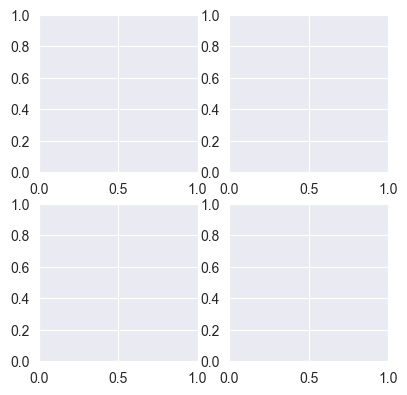

In [34]:
fig, axes = plt.subplots(2,2, figsize=(4.5, 4.5))

In [35]:
def plot_boundary(ax, data, tgt, model, dims, grid_step = .01):
    twoD = data[:, list(dims)]
    min_x1, min_x2 = np.min(twoD, axis=0) + 2 * grid_step
    max_x1, max_x2 = np.max(twoD, axis=0) - grid_step
    xs, ys = np.mgrid[min_x1:max_x1:grid_step, min_x2:max_x2:grid_step]
    grid_points = np.c_[xs.ravel(), ys.ravel()]
    preds = model.fit(twoD, tgt).predict(grid_points).reshape(xs.shape)
    ax.pcolormesh(xs,ys,preds,cmap=plt.cm.coolwarm)
    ax.set_xlim(min_x1, max_x1)
    ax.set_ylim(min_x2, max_x2)

In [36]:
iris = datasets.load_iris()

In [37]:
for model, ax, name in zip(da_methods, axes.flat, names):
    plot_boundary(ax, iris.data, iris.target, model, [0,1])
    ax.set_title(name)

plt.tight_layout()

<Figure size 640x480 with 0 Axes>